In [1]:
import numpy as np

from mgwr.gwr import GWR as OfficialGWR
from mgwr.sel_bw import Sel_BW

from src.log.gwr_logger import GwrLogger
from src.kernel.gwr_kernel import GwrKernel
from src.model.gwr import GWR
from src.dataset.simulated_spatial_dataset import SimulatedSpatialDataset
from src.model.lgwr import LGWR
from src.kernel.lgwr_kernel import LgwrKernel

k = 1
field_size = 40

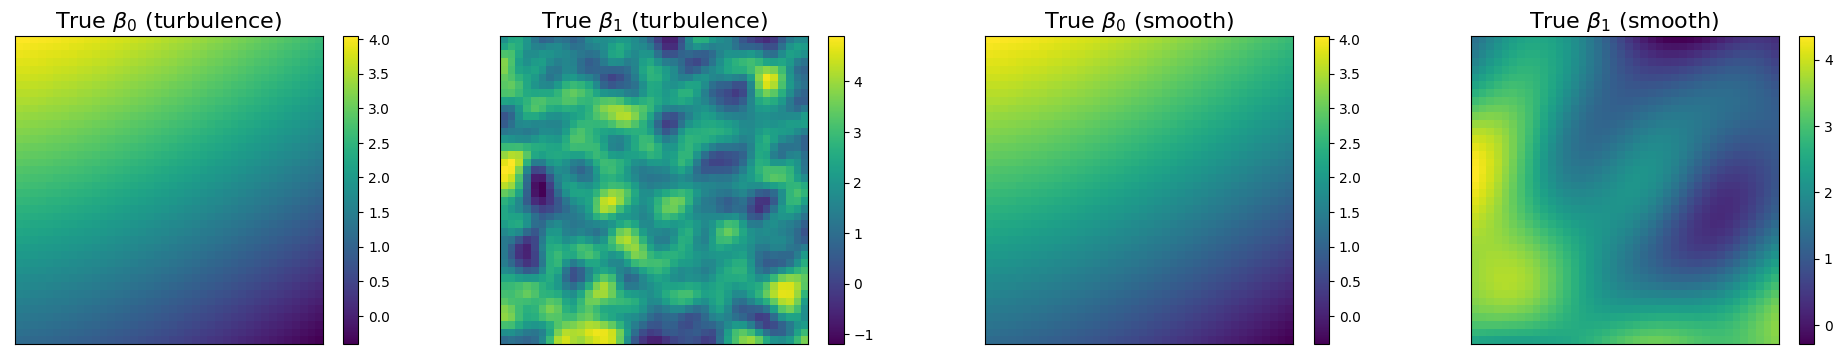

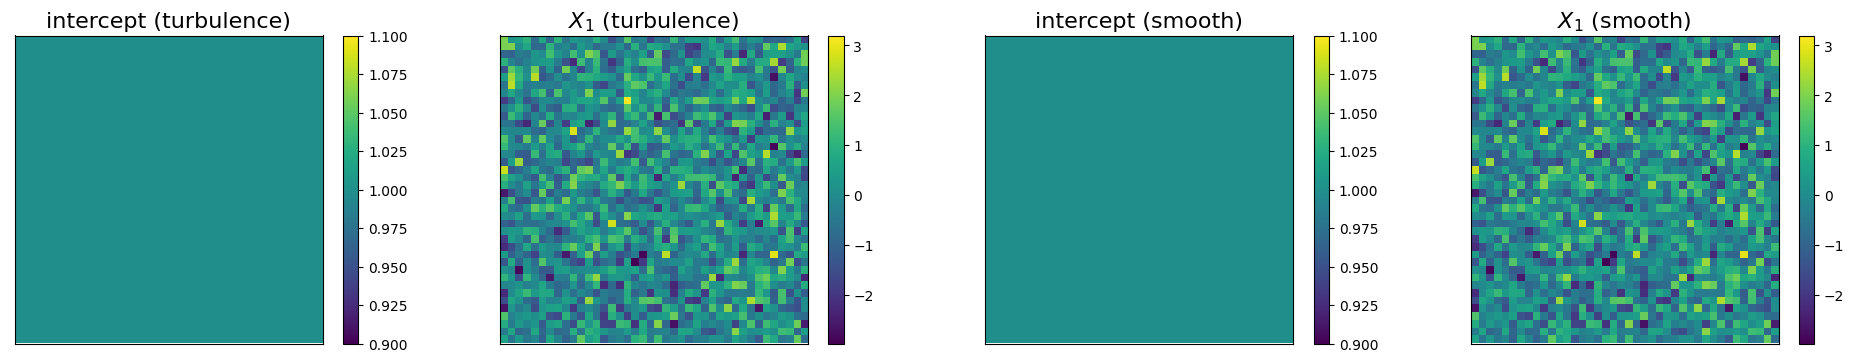

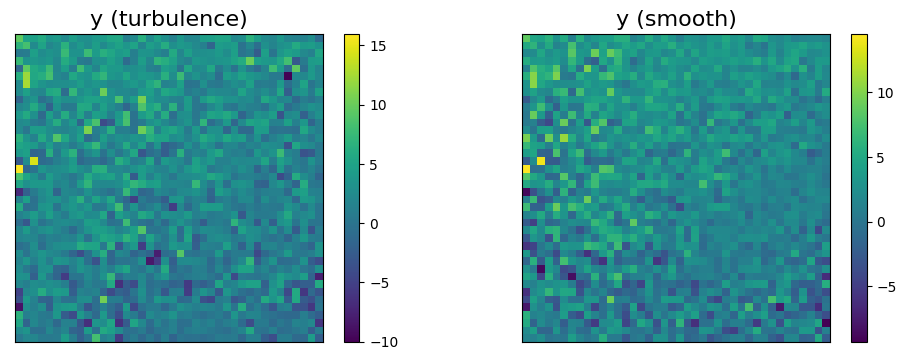

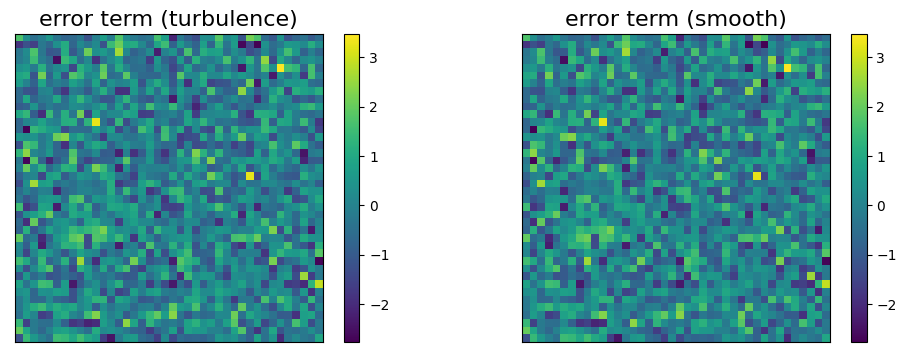

In [18]:

dataset_turbulence = SimulatedSpatialDataset(
    k=k,
    field_size=field_size,
    process_seed=[666, 888],
    len_scale_seed=[100, 2]
)
[X_turbulence] = dataset_turbulence.generate_data()
[beta_turbulence] = dataset_turbulence.generate_processes()
[y_turbulence, err_turbulence] = dataset_turbulence.fit_y(
    X_turbulence, beta_turbulence
)

dataset_smooth = SimulatedSpatialDataset(
    k=k,
    field_size=field_size,
    process_seed=[666, 888],
    len_scale_seed=[100, 10]
)
[X_smooth] = dataset_smooth.generate_data()
[beta_smooth] = dataset_smooth.generate_processes()
[y_smooth, err_smooth] = dataset_smooth.fit_y(
    X_smooth, beta_smooth
)


dataset_turbulence.plot(
    b=np.vstack([
        beta_turbulence.T, 
        beta_smooth.T
    ]),
    sub_title=[
        r"True $\beta_0$ (turbulence)", 
        r"True $\beta_1$ (turbulence)", 
        r"True $\beta_0$ (smooth)",
        r"True $\beta_1$ (smooth)"
    ],
    size=field_size
)

dataset_turbulence.plot(
    b=np.vstack([
        X_turbulence.T, 
        X_smooth.T
    ]),
    sub_title=[
        r"intercept (turbulence)", 
        r"$X_1$ (turbulence)", 
        r"intercept (smooth)", 
        r"$X_1$ (smooth)"
    ],
    size=field_size
)

dataset_turbulence.plot(
    b=np.vstack([
        y_turbulence.reshape(1, -1), 
        y_smooth.reshape(1, -1)
    ]),
    sub_title=[
        'y (turbulence)', 
        'y (smooth)'
    ],
    size=field_size
)

dataset_turbulence.plot(
    b=np.vstack([
        err_turbulence.reshape(1, -1), 
        err_smooth.reshape(1, -1)
    ]),
    sub_title=[
        'error term (turbulence)', 
        'error term (smooth)'
        ],
    size=field_size
)

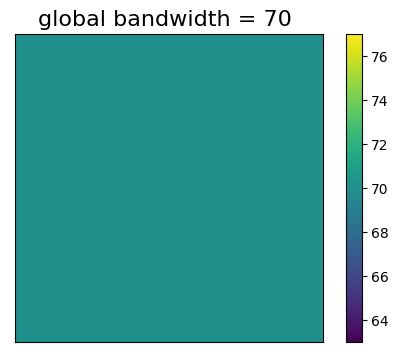

In [3]:


dataset_turbulence.plot(
    b=np.full(dataset_turbulence.n, 70).reshape(1, -1),
    sub_title=['global bandwidth = 70 '],
    size=field_size
)

use golden search to find a global optimal bandwidth

In [19]:
g_X_turbulence = dataset_turbulence.X[:, 1:]
g_y_turbulence = dataset_turbulence.y.reshape(-1, 1)
g_coords_turbulence = dataset_turbulence.coordinates.tolist()

gwr_selector_turbulence = Sel_BW(
    g_coords_turbulence, 
    g_y_turbulence, 
    g_X_turbulence
)
gwr_bw_turbulence = gwr_selector_turbulence.search(bw_min=2)
official_gwr_turbulence = OfficialGWR(
    g_coords_turbulence, 
    g_y_turbulence, 
    g_X_turbulence, 
    gwr_bw_turbulence
).fit()


g_X_smooth = dataset_smooth.X[:, 1:]
g_y_smooth = dataset_smooth.y.reshape(-1, 1)
g_coords_smooth = dataset_smooth.coordinates.tolist()
gwr_selector_smooth = Sel_BW(
    g_coords_smooth, 
    g_y_smooth, 
    g_X_smooth
)
gwr_bw_smooth = gwr_selector_smooth.search(bw_min=2)
official_gwr_smooth = OfficialGWR(
    g_coords_smooth, 
    g_y_smooth, 
    g_X_smooth, 
    gwr_bw_smooth
).fit()

In [20]:
# formatted comparison between the two official GWR fits
print("="*60)
print("GWR Model Comparison")
print("="*60)
print(f"{'Metric':30} {'Turbulence':>12} {'Smooth':>15}")
print("-"*60)
print(f"{'Global bandwidth':30} {int(gwr_bw_turbulence):12d} {int(gwr_bw_smooth):15d}")
print(f"{'R-squared':30} {official_gwr_turbulence.R2:12.4f} {official_gwr_smooth.R2:15.4f}")
print(f"{'AIC':30} {official_gwr_turbulence.aic:12.2f} {official_gwr_smooth.aic:15.2f}")
print(f"{'AICc':30} {official_gwr_turbulence.aicc:12.2f} {official_gwr_smooth.aicc:15.2f}")
print("-"*60)
print("="*60)

GWR Model Comparison
Metric                           Turbulence          Smooth
------------------------------------------------------------
Global bandwidth                         44             103
R-squared                            0.8687          0.8684
AIC                                 4875.78         4555.78
AICc                                4942.36         4565.68
------------------------------------------------------------


Reload LGWR log files

In [8]:
from src.reload.lgwr_reload import reload_logs, reload_lgwr

bandwidth_sets_smooth = reload_logs(r"./logs/one-beta-lgwr/smooth/model_info.json")
bandwidth_sets_turbulence = reload_logs(r"./logs/one-beta-lgwr/turbulence/model_info.json")

In [9]:
lower_aicc_smooth_bw_sets = []
for bw_set in bandwidth_sets_smooth:
    if float(bw_set["reward"]) <= official_gwr_smooth.aicc:
        lower_aicc_smooth_bw_sets.append(bw_set)

lower_aicc_turbulence_bw_sets = []
for bw_set in bandwidth_sets_turbulence:
    if float(bw_set["reward"]) <= official_gwr_turbulence.aicc:
        lower_aicc_turbulence_bw_sets.append(bw_set)

print(f"smooth: {len(lower_aicc_smooth_bw_sets)} / {len(bandwidth_sets_smooth)}")
print(f"turbulence: {len(lower_aicc_turbulence_bw_sets)} / {len(bandwidth_sets_turbulence)}")

smooth: 645 / 729
turbulence: 620 / 726


In [10]:
best_bw_set_smooth = min(lower_aicc_smooth_bw_sets, key=lambda s: float(s['reward']))
print(f"best smooth episode: {best_bw_set_smooth['episode']}, reward: {best_bw_set_smooth['reward']}, r2: {best_bw_set_smooth.get('r2')}")
best_bw = best_bw_set_smooth['bandwidth']

best_bw_set_turbulence = min(lower_aicc_turbulence_bw_sets, key=lambda s: float(s['reward']))
print(f"best turbulence episode: {best_bw_set_turbulence['episode']}, reward: {best_bw_set_turbulence['reward']}, r2: {best_bw_set_turbulence.get('r2')}")
best_bw = best_bw_set_turbulence['bandwidth']

best smooth episode: 662, reward: 4507.9113598112, r2: 0.8703476728193946
best turbulence episode: 725, reward: 4914.812341248852, r2: 0.8684777818147513


In [11]:
lgwr_smooth = reload_lgwr(dataset_smooth, best_bw_set_smooth)
lgwr_turbulence = reload_lgwr(dataset_turbulence, best_bw_set_turbulence)

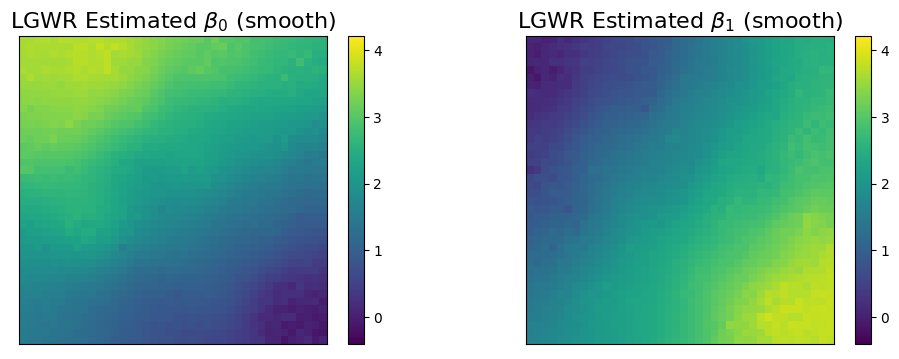

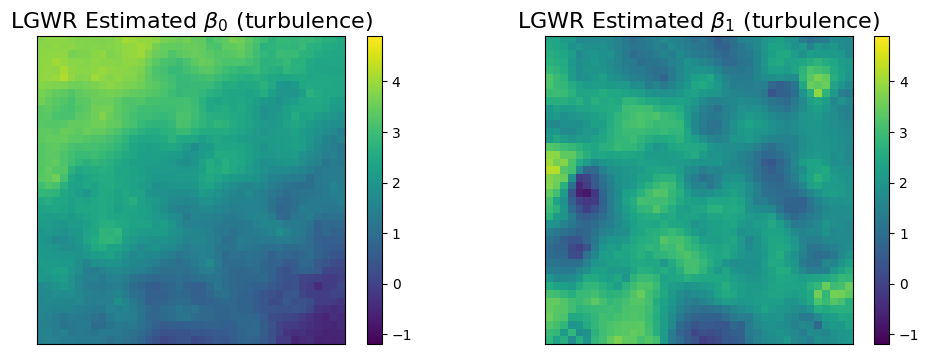

In [12]:
dataset_smooth.plot(
    b=lgwr_smooth.betas.T,
    sub_title=[
        r"LGWR Estimated $\beta_0$ (smooth)", 
        r"LGWR Estimated $\beta_1$ (smooth)"
    ],
    size=field_size,
    vmin=beta_smooth.min(), vmax=beta_smooth.max()
)

dataset_turbulence.plot(
    b=lgwr_turbulence.betas.T,
    sub_title=[
        r"LGWR Estimated $\beta_0$ (turbulence)", 
        r"LGWR Estimated $\beta_1$ (turbulence)"
    ],
    size=field_size,
    vmin=beta_turbulence.min(), vmax=beta_turbulence.max()
)

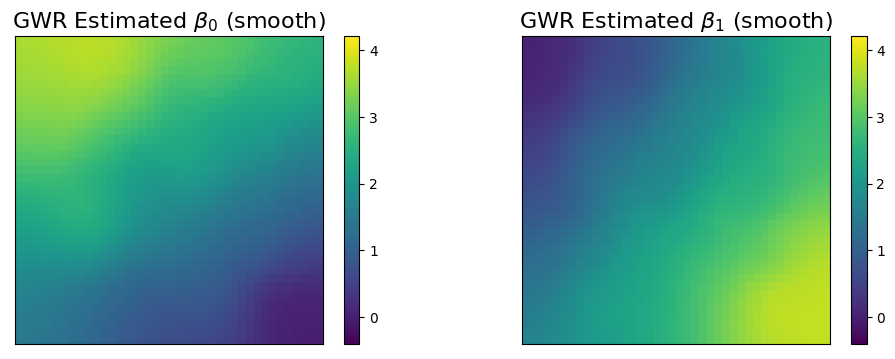

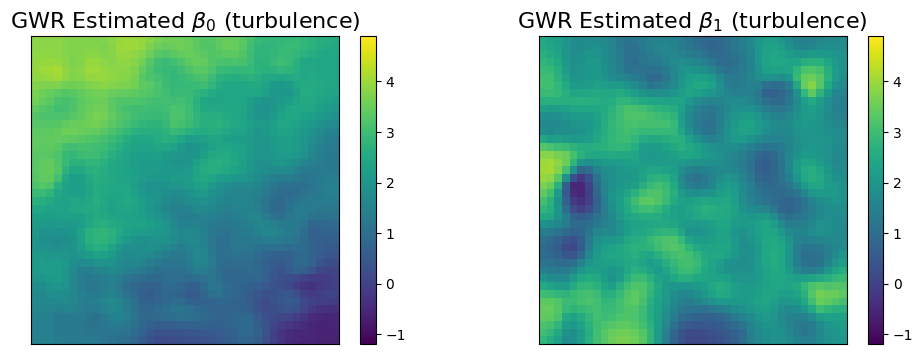

In [13]:
dataset_smooth.plot(
    b=official_gwr_smooth.params.T,
    sub_title=[
        r"GWR Estimated $\beta_0$ (smooth)", 
        r"GWR Estimated $\beta_1$ (smooth)"
    ],
    size=field_size,
    vmin=beta_smooth.min(), vmax=beta_smooth.max()
)

dataset_turbulence.plot(
    b=official_gwr_turbulence.params.T,
    sub_title=[
        r"GWR Estimated $\beta_0$ (turbulence)", 
        r"GWR Estimated $\beta_1$ (turbulence)"
    ],
    size=field_size,
    vmin=beta_turbulence.min(), vmax=beta_turbulence.max()
)

In [14]:
print(lgwr_smooth.betas.shape)
print(lgwr_turbulence.betas.shape)

print(official_gwr_smooth.params.shape)
print(official_gwr_turbulence.params.shape)

def _align(true, est):
    est = np.asarray(est)
    if est.shape == true.shape:
        return est
    if est.T.shape == true.shape:
        return est.T
    try:
        return est.reshape(true.shape)
    except Exception as e:
        raise ValueError(f"Cannot align shapes true:{true.shape} est:{est.shape}") from e

# Smooth
true_smooth = np.asarray(beta_smooth)
lgwr_smooth_est = _align(true_smooth, lgwr_smooth.betas)
gwr_smooth_est = _align(true_smooth, official_gwr_smooth.params)

mse_lgwr_smooth_per_param = np.mean((true_smooth - lgwr_smooth_est) ** 2, axis=0)
mse_lgwr_smooth_overall = np.mean((true_smooth - lgwr_smooth_est) ** 2)

mse_gwr_smooth_per_param = np.mean((true_smooth - gwr_smooth_est) ** 2, axis=0)
mse_gwr_smooth_overall = np.mean((true_smooth - gwr_smooth_est) ** 2)

# Turbulence
true_turb = np.asarray(beta_turbulence)
lgwr_turb_est = _align(true_turb, lgwr_turbulence.betas)
gwr_turb_est = _align(true_turb, official_gwr_turbulence.params)

mse_lgwr_turb_per_param = np.mean((true_turb - lgwr_turb_est) ** 2, axis=0)
mse_lgwr_turb_overall = np.mean((true_turb - lgwr_turb_est) ** 2)

mse_gwr_turb_per_param = np.mean((true_turb - gwr_turb_est) ** 2, axis=0)
mse_gwr_turb_overall = np.mean((true_turb - gwr_turb_est) ** 2)

# Print results
print("Smooth:")
print("  LGWR mse per param:", mse_lgwr_smooth_per_param)
print("  LGWR mse overall:   {:.6e}".format(mse_lgwr_smooth_overall))
print("  GWR  mse per param:", mse_gwr_smooth_per_param)
print("  GWR  mse overall:   {:.6e}".format(mse_gwr_smooth_overall))
print()
print("Turbulence:")
print("  LGWR mse per param:", mse_lgwr_turb_per_param)
print("  LGWR mse overall:   {:.6e}".format(mse_lgwr_turb_overall))
print("  GWR  mse per param:", mse_gwr_turb_per_param)
print("  GWR  mse overall:   {:.6e}".format(mse_gwr_turb_overall))


(1600, 2)
(1600, 2)
(1600, 2)
(1600, 2)
Smooth:
  LGWR mse per param: [0.01528602 0.01610088]
  LGWR mse overall:   1.569345e-02
  GWR  mse per param: [0.01405016 0.01511131]
  GWR  mse overall:   1.458074e-02

Turbulence:
  LGWR mse per param: [0.05517473 0.34947064]
  LGWR mse overall:   2.023227e-01
  GWR  mse per param: [0.05811215 0.32057523]
  GWR  mse overall:   1.893437e-01


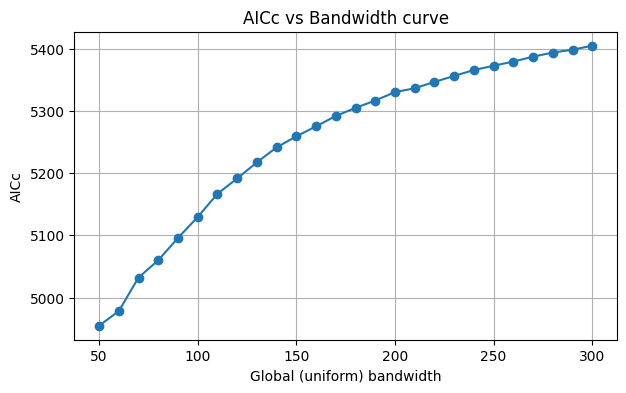

In [ ]:

import matplotlib.pyplot as plt

lgwr_smooth = lgwr_turbulence
lgwr_smooth.update_local_bandwidth_vector(np.full(dataset_smooth.n, 103)).fit()

# 假設 lgwr_smooth 與 dataset_smooth 已建立完畢
# 準備帶寬範圍，例如從 50 到 300，每隔 10 一步
bandwidths = np.arange(50, 301, 10)
aicc_values = []

for bw in bandwidths:
    # 更新所有地點的帶寬為相同值
    lgwr_smooth.update_local_bandwidth_vector(np.full(dataset_smooth.n, bw))
    
    # 重新擬合模型
    lgwr_smooth.fit()
    
    # 取得 AICc
    aicc_values.append(lgwr_smooth.aicc)

# 繪圖
plt.figure(figsize=(7, 4))
plt.plot(bandwidths, aicc_values, marker='o')
plt.xlabel("Global (uniform) bandwidth")
plt.ylabel("AICc")
plt.title("AICc vs Bandwidth curve")
plt.grid(True)
plt.show()

change only two points

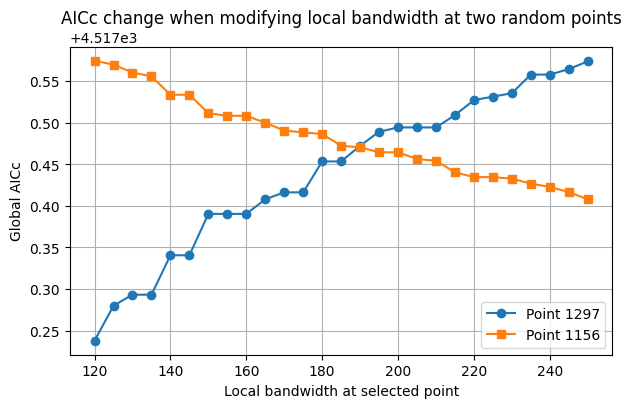

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 隨機挑兩個地點
np.random.seed(44) #43
idx1, idx2 = np.random.choice(dataset_smooth.n, size=2, replace=False)

# 定義要測的帶寬範圍
bandwidths = np.arange(120, 251, 5)

aicc_curve_1 = []
aicc_curve_2 = []

# 以 186 為基準帶寬
base_bw = np.full(dataset_smooth.n, 186)

# 只改變第 idx1 個地點的帶寬
for bw in bandwidths:
    bw_vec = base_bw.copy()
    bw_vec[idx1] = bw
    lgwr_smooth.update_local_bandwidth_vector(bw_vec)
    lgwr_smooth.fit()
    aicc_curve_1.append(lgwr_smooth.aicc)

# 只改變第 idx2 個地點的帶寬
for bw in bandwidths:
    bw_vec = base_bw.copy()
    bw_vec[idx2] = bw
    lgwr_smooth.update_local_bandwidth_vector(bw_vec)
    lgwr_smooth.fit()
    aicc_curve_2.append(lgwr_smooth.aicc)

# 繪圖
plt.figure(figsize=(7, 4))
plt.plot(bandwidths, aicc_curve_1, marker='o', label=f"Point {idx1}")
plt.plot(bandwidths, aicc_curve_2, marker='s', label=f"Point {idx2}")
plt.xlabel("Local bandwidth at selected point")
plt.ylabel("Global AICc")
plt.title("AICc change when modifying local bandwidth at two random points")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
bw_vec = base_bw.copy()
bw_vec[idx1] = 120
bw_vec[idx2] = 240
lgwr_smooth.update_local_bandwidth_vector(bw_vec).fit()
print(lgwr_smooth.aicc)
print(official_gwr_smooth.aicc)


4517.188347646144
4517.472300725309


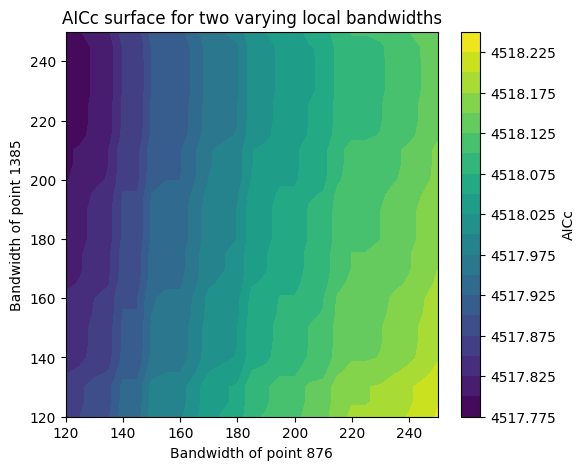

In [17]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(46)
idx1, idx2 = np.random.choice(dataset_smooth.n, size=2, replace=False)

bw_range = np.arange(120, 251, 5)
aicc_surface = np.zeros((len(bw_range), len(bw_range)))

base_bw = np.full(dataset_smooth.n, 183)

for i, bw1 in enumerate(bw_range):
    for j, bw2 in enumerate(bw_range):
        bw_vec = base_bw.copy()
        bw_vec[idx1] = bw1
        bw_vec[idx2] = bw2
        lgwr_smooth.update_local_bandwidth_vector(bw_vec)
        lgwr_smooth.fit()
        aicc_surface[i, j] = lgwr_smooth.aicc

plt.figure(figsize=(6, 5))
plt.contourf(bw_range, bw_range, aicc_surface.T, levels=20, cmap="viridis")
plt.xlabel(f"Bandwidth of point {idx1}")
plt.ylabel(f"Bandwidth of point {idx2}")
plt.title("AICc surface for two varying local bandwidths")
plt.colorbar(label="AICc")
plt.show()


change cluster

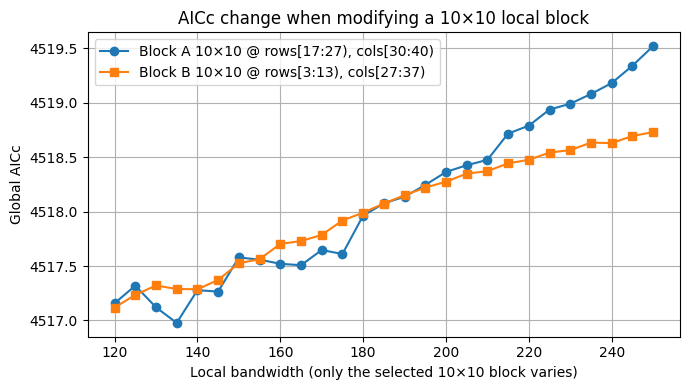

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ========= 基本設定 =========
np.random.seed(48)
bandwidths = np.arange(120, 251, 5)
base_bw_val = 183
block_size = 10

# 假設資料是 n_side × n_side 規則網格
n_total = dataset_smooth.n
n_side = int(np.sqrt(n_total))
assert n_side * n_side == n_total, "資料不是正方網格，請改成提供 (rows, cols)。"

def idx_to_rc(idx, n_side):
    r = idx // n_side
    c = idx % n_side
    return r, c

def rc_to_idx(r, c, n_side):
    return r * n_side + c

def window_start(center, size, n_side):
    half = size // 2
    start = center - half
    if start < 0:
        start = 0
    if start + size > n_side:
        start = n_side - size
    return start

def block_indices(center_idx, size, n_side):
    """以 center_idx 為中心取 size×size 方格，必要時沿邊界內縮。"""
    r0, c0 = idx_to_rc(center_idx, n_side)
    rs = window_start(r0, size, n_side)
    cs = window_start(c0, size, n_side)
    inds = [rc_to_idx(r, c, n_side) for r in range(rs, rs+size) for c in range(cs, cs+size)]
    return np.array(inds, dtype=int), (rs, cs)

# ========= 隨機兩個中心並建兩個 10×10 方格 =========
idx1, idx2 = np.random.choice(n_total, size=2, replace=False)
block1, (r1s, c1s) = block_indices(idx1, block_size, n_side)
block2, (r2s, c2s) = block_indices(idx2, block_size, n_side)

# ========= 掃描並繪兩條曲線 =========
aicc_curve_1 = []  # 只改變 block1
aicc_curve_2 = []  # 只改變 block2
base_bw = np.full(n_total, base_bw_val)

# 只改變方格1，其餘（含方格2）固定 183
for bw in bandwidths:
    bw_vec = base_bw.copy()
    bw_vec[block1] = bw
    lgwr_smooth.update_local_bandwidth_vector(bw_vec)
    lgwr_smooth.fit()
    aicc_curve_1.append(lgwr_smooth.aicc)

# 只改變方格2，其餘（含方格1）固定 183
for bw in bandwidths:
    bw_vec = base_bw.copy()
    bw_vec[block2] = bw
    lgwr_smooth.update_local_bandwidth_vector(bw_vec)
    lgwr_smooth.fit()
    aicc_curve_2.append(lgwr_smooth.aicc)

# ========= 繪圖 =========
plt.figure(figsize=(7, 4))
plt.plot(bandwidths, aicc_curve_1, marker='o',
         label=f"Block A 10×10 @ rows[{r1s}:{r1s+block_size}), cols[{c1s}:{c1s+block_size})")
plt.plot(bandwidths, aicc_curve_2, marker='s',
         label=f"Block B 10×10 @ rows[{r2s}:{r2s+block_size}), cols[{c2s}:{c2s+block_size})")
plt.xlabel("Local bandwidth (only the selected 10×10 block varies)")
plt.ylabel("Global AICc")
plt.title("AICc change when modifying a 10×10 local block")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


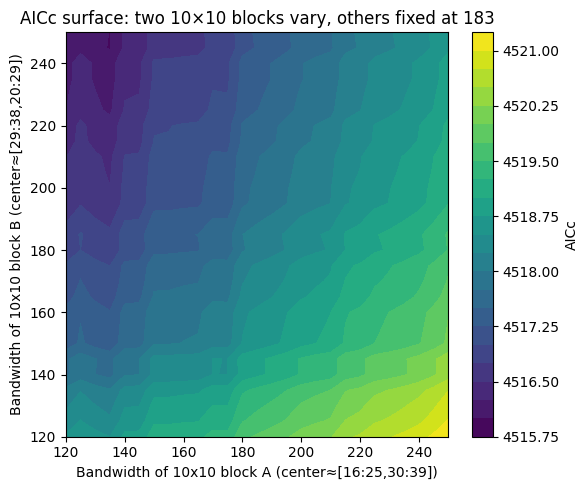

Total combos: 729, unique AICc values: 729


In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ===== 基本設定 =====
np.random.seed(46)
bw_range = np.arange(120, 251, 5)  # 帶寬掃描範圍
base_bw_val = 183                   # 其他位置固定帶寬
block_size = 10                     # 每個方格 10x10

# 嘗試從 dataset_smooth.n 推回是方格網 (n = nrow*ncol)
n_total = dataset_smooth.n
n_side = int(np.sqrt(n_total))
assert n_side * n_side == n_total, "資料不是正方網格，請提供 (rows, cols)。"

def idx_to_rc(idx, n_side):
    r = idx // n_side
    c = idx % n_side
    return r, c

def rc_to_idx(r, c, n_side):
    return r * n_side + c

def window_start(center, size, n_side):
    """回傳使得 [start, start+size) 完整落在 [0, n_side) 的起點"""
    half = size // 2
    start = center - half
    if start < 0:
        start = 0
    if start + size > n_side:
        start = n_side - size
    return start

def block_indices(center_idx, size, n_side):
    """回傳以 center_idx 為中心、大小為 size×size 的方格的一維索引集合
       若在邊界，會自動平移以確保完整 size×size。"""
    r0, c0 = idx_to_rc(center_idx, n_side)
    rs = window_start(r0, size, n_side)
    cs = window_start(c0, size, n_side)
    rs_rng = range(rs, rs + size)
    cs_rng = range(cs, cs + size)
    inds = [rc_to_idx(r, c, n_side) for r in rs_rng for c in cs_rng]
    return np.array(inds, dtype=int), (rs, cs)

# ===== 隨機兩個中心並建方格 =====
idx1, idx2 = np.random.choice(n_total, size=2, replace=False)
block1, (r1s, c1s) = block_indices(idx1, block_size, n_side)
block2, (r2s, c2s) = block_indices(idx2, block_size, n_side)

# ===== 掃描兩個方格的帶寬 (bw1, bw2) =====
aicc_surface = np.zeros((len(bw_range), len(bw_range)))
base_bw = np.full(n_total, base_bw_val)

for i, bw1 in enumerate(bw_range):
    for j, bw2 in enumerate(bw_range):
        bw_vec = base_bw.copy()
        bw_vec[block1] = bw1
        bw_vec[block2] = bw2
        lgwr_smooth.update_local_bandwidth_vector(bw_vec)
        lgwr_smooth.fit()
        aicc_surface[i, j] = lgwr_smooth.aicc

# ===== 視覺化 =====
plt.figure(figsize=(6, 5))
cf = plt.contourf(bw_range, bw_range, aicc_surface.T, levels=20, cmap="viridis")
plt.colorbar(cf, label="AICc")
plt.xlabel(f"Bandwidth of 10x10 block A (center≈[{r1s}:{r1s+block_size-1},{c1s}:{c1s+block_size-1}])")
plt.ylabel(f"Bandwidth of 10x10 block B (center≈[{r2s}:{r2s+block_size-1},{c2s}:{c2s+block_size-1}])")
plt.title("AICc surface: two 10×10 blocks vary, others fixed at 183")
plt.tight_layout()
plt.show()

# ===== 數值證據（unique 個數）=====
uniq_cnt = np.unique(np.round(aicc_surface, 5)).size
print(f"Total combos: {aicc_surface.size}, unique AICc values: {uniq_cnt}")


{'count_smaller': 624, 'count_larger': 976, 'count_tie': 0, 'baseline_aicc': 4518.033828445565, 'final_aicc': 4466.7991209001275, 'delta_aicc': -51.23470754543723}


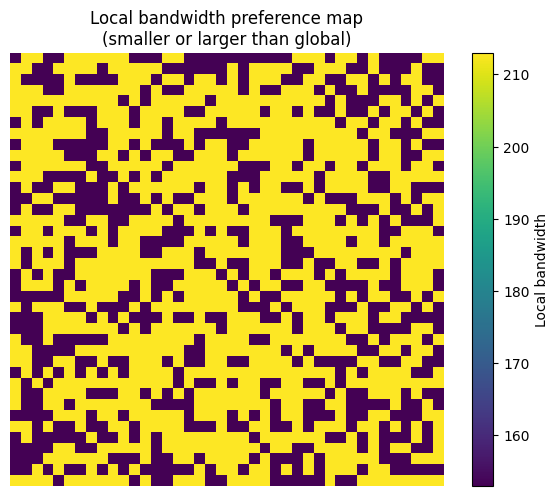

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- 你的函式（上面那段） ----------
def pick_local_bandwidths(
    lgwr,
    n_points: int,
    global_bw: int,
    delta_down: int = 30,
    delta_up: int = 30,
    min_bw: int = 20,
    max_bw: int = 500,
):
    base_vec = np.full(n_points, global_bw, dtype=int)

    # baseline AICc
    lgwr.update_local_bandwidth_vector(base_vec)
    lgwr.fit()
    baseline_aicc = lgwr.aicc

    final_bw = base_vec.copy()
    choice = np.zeros(n_points, dtype=np.int8)  # -1 smaller, 0 tie, +1 larger

    small_bw_val = int(max(min_bw, global_bw - delta_down))
    large_bw_val = int(min(max_bw, global_bw + delta_up))

    for i in range(n_points):
        vec_small = base_vec.copy()
        vec_small[i] = small_bw_val
        lgwr.update_local_bandwidth_vector(vec_small)
        lgwr.fit()
        aicc_small = lgwr.aicc

        vec_large = base_vec.copy()
        vec_large[i] = large_bw_val
        lgwr.update_local_bandwidth_vector(vec_large)
        lgwr.fit()
        aicc_large = lgwr.aicc

        if aicc_small < aicc_large - 1e-9:
            choice[i] = -1
            final_bw[i] = small_bw_val
        elif aicc_large < aicc_small - 1e-9:
            choice[i] = +1
            final_bw[i] = large_bw_val
        else:
            choice[i] = 0

    lgwr.update_local_bandwidth_vector(final_bw)
    lgwr.fit()
    final_aicc = lgwr.aicc

    summary = {
        "count_smaller": int(np.sum(choice == -1)),
        "count_larger": int(np.sum(choice == +1)),
        "count_tie": int(np.sum(choice == 0)),
        "baseline_aicc": float(baseline_aicc),
        "final_aicc": float(final_aicc),
        "delta_aicc": float(final_aicc - baseline_aicc),
    }
    return final_bw, choice, summary


# ---------- 執行 ----------
global_bw = 183
final_bw, choice, summary = pick_local_bandwidths(
    lgwr=lgwr_smooth,
    n_points=dataset_smooth.n,
    global_bw=global_bw,
    delta_down=30,
    delta_up=30,
    min_bw=20,
    max_bw=500,
)

print(summary)

# ---------- 繪製 local bandwidth map ----------
n_side = int(np.sqrt(dataset_smooth.n))  # 假設是規則方格
bw_map = final_bw.reshape(n_side, n_side)

plt.figure(figsize=(6, 5))
im = plt.imshow(bw_map, cmap="viridis", origin="lower")
plt.colorbar(im, label="Local bandwidth")
plt.title("Local bandwidth preference map\n(smaller or larger than global)")
plt.axis("off")
plt.tight_layout()
plt.show()


In [21]:
from pprint import pprint
pprint(summary)

{'baseline_aicc': 4518.033828445565,
 'count_larger': 976,
 'count_smaller': 624,
 'count_tie': 0,
 'delta_aicc': -51.23470754543723,
 'final_aicc': 4466.7991209001275}


In [22]:
lgwr_smooth.update_local_bandwidth_vector(final_bw).fit()
lgwr_smooth.aicc

4466.7991209001275

In [23]:
final_bw

array([213, 213, 213, ..., 153, 213, 213])